# CityBite — End-to-End Analysis Notebook

This notebook demonstrates the full CityBite pipeline on the **local sample dataset** — no AWS required.
All cells run against `data/citybite_local.db` (SQLite) and `data/processed/` (Parquet).

## Pipeline recap

```
Yelp JSON  →  clean_job.py (PySpark)  →  reviews_enriched/ (Parquet)
                                      →  aggregate_job.py  →  business_scores / grid_aggregates
                                      →  als_train.py      →  als_recommendations
                                      →  sentiment.py      →  grid_sentiment
```

All four output tables are loaded below from the local SQLite DB.

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine, text

# Locate project root (one level up from notebooks/)
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

DB_PATH = os.path.join(ROOT, 'data', 'citybite_local.db')
PROCESSED = os.path.join(ROOT, 'data', 'processed')
SAMPLE    = os.path.join(ROOT, 'data', 'sample')

engine = create_engine(f'sqlite:///{DB_PATH}')
print(f'DB: {DB_PATH}')
print(f'Processed data: {PROCESSED}')

DB: /Users/edwinrivera/Spring2026/CS4266/CityBite/data/citybite_local.db
Processed data: /Users/edwinrivera/Spring2026/CS4266/CityBite/data/processed


---
## 1. Raw Data Overview

Load the Yelp sample JSON files to show what the pipeline starts with.

In [2]:
import json

def load_jsonl(path):
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return pd.DataFrame(records)

biz_raw = load_jsonl(os.path.join(SAMPLE, 'yelp_academic_dataset_business.json'))
rev_raw = load_jsonl(os.path.join(SAMPLE, 'yelp_academic_dataset_review.json'))

print(f'Raw businesses : {len(biz_raw):,} rows, columns: {biz_raw.columns.tolist()}')
print(f'Raw reviews    : {len(rev_raw):,} rows, columns: {rev_raw.columns.tolist()}')
print()
print('Cities in sample:')
print(biz_raw['city'].value_counts().head(10).to_string())

Raw businesses : 300 rows, columns: ['business_id', 'name', 'city', 'state', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'categories']
Raw reviews    : 3,000 rows, columns: ['review_id', 'user_id', 'business_id', 'stars', 'date', 'text', 'useful', 'funny', 'cool']

Cities in sample:
city
Phoenix      100
Las Vegas    100
Charlotte    100


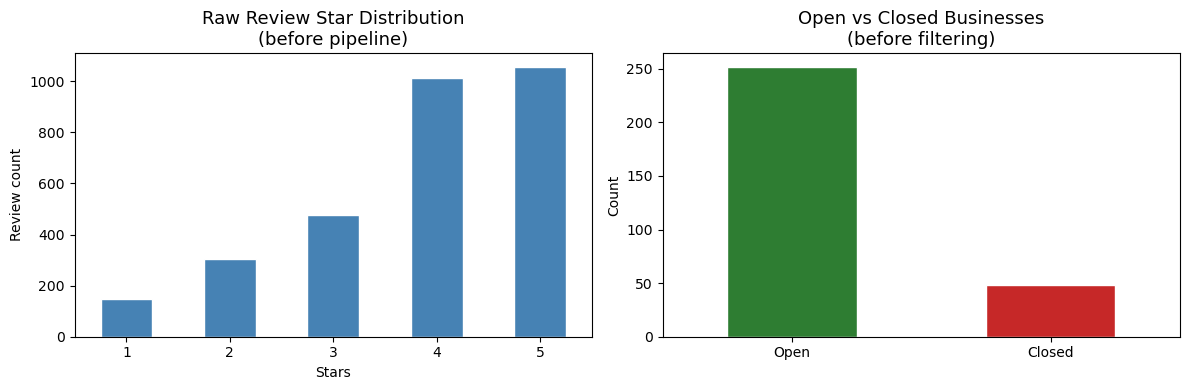

Saved → assets/fig_raw_data.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw star distribution
rev_raw['stars'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Raw Review Star Distribution\n(before pipeline)', fontsize=13)
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Review count')
axes[0].tick_params(axis='x', rotation=0)

# Open vs closed businesses
biz_raw['is_open'].map({1: 'Open', 0: 'Closed'}).value_counts().plot(
    kind='bar', ax=axes[1], color=['#2e7d32', '#c62828'], edgecolor='white')
axes[1].set_title('Open vs Closed Businesses\n(before filtering)', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../assets/fig_raw_data.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → assets/fig_raw_data.png')

---
## 2. Before vs After — Raw Stars vs Popularity Score

The key claim of the pipeline: a plain star average is a poor guide.
The `popularity_score` formula combines rating quality, review volume (log-scaled), and recency to produce a richer signal.

```
popularity_score = 0.4 × avg_rating
                 + 0.4 × log(review_count + 1)
                 + 0.2 × avg(recency_weight)
```

In [4]:
with engine.connect() as conn:
    biz = pd.read_sql(text('SELECT * FROM business_scores'), conn)
    grid = pd.read_sql(text('SELECT * FROM grid_aggregates'), conn)

print(f'business_scores : {len(biz):,} rows across cities: {sorted(biz["city"].unique())}')
print(f'grid_aggregates : {len(grid):,} grid cells')
biz.head(3)

business_scores : 252 rows across cities: ['Charlotte', 'Las Vegas', 'Phoenix']
grid_aggregates : 119 grid cells


,business_id,name,city,latitude,longitude,grid_cell,categories,avg_rating,review_count,recency_score,popularity_score
0,nvlIMPhv6k20QjgK0zLBDp,La Fast Food Spot,Las Vegas,36.116002,-115.298282,36.1_-115.3,"Fast Food, Restaurants",3.500000,8,0.415912,2.362072
1,6CbOUj41HbdWRb7PZiqBBc,La Thai Grill,Las Vegas,36.361464,-115.368727,36.3_-115.4,"Thai, Restaurants",3.733333,15,0.347464,2.671862
2,I2vFyBLHEAX1flPURVihIf,Cafe Pizza Spot,Las Vegas,36.346446,-115.290469,36.3_-115.3,"Pizza, Restaurants",4.090909,11,0.354749,2.701276


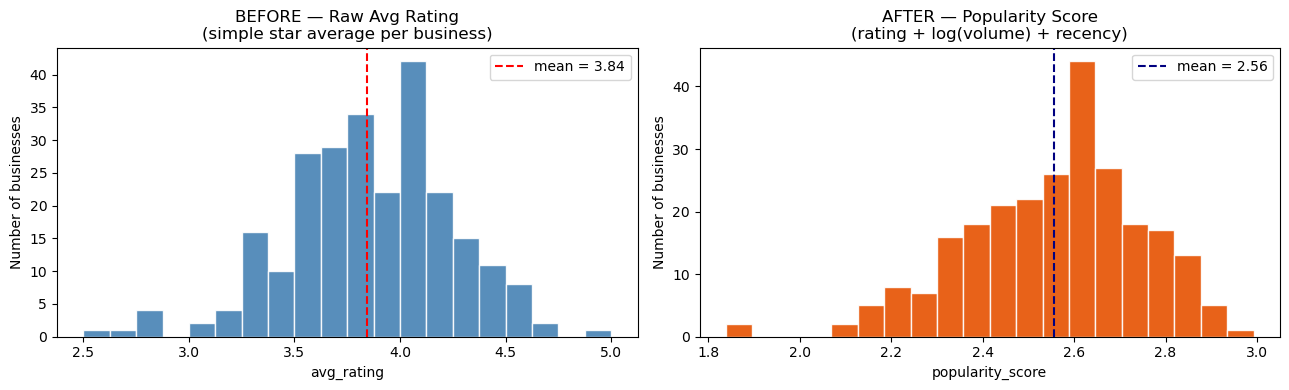

Saved → assets/fig_before_after.png

Distribution summary:
       avg_rating  review_count  recency_score  popularity_score
count     252.000       252.000        252.000           252.000
mean        3.842        10.179          0.355             2.557
std         0.389         3.062          0.063             0.193
min         2.500         3.000          0.219             1.838
25%         3.600         8.000          0.311             2.437
50%         3.857        10.000          0.353             2.585
75%         4.093        12.000          0.394             2.691
max         5.000        20.000          0.559             2.993


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Before: raw avg_rating distribution
axes[0].hist(biz['avg_rating'], bins=20, color='steelblue', edgecolor='white', alpha=0.9)
axes[0].set_title('BEFORE — Raw Avg Rating\n(simple star average per business)', fontsize=12)
axes[0].set_xlabel('avg_rating')
axes[0].set_ylabel('Number of businesses')
axes[0].axvline(biz['avg_rating'].mean(), color='red', linestyle='--', label=f'mean = {biz["avg_rating"].mean():.2f}')
axes[0].legend()

# After: popularity_score distribution
axes[1].hist(biz['popularity_score'], bins=20, color='#e65100', edgecolor='white', alpha=0.9)
axes[1].set_title('AFTER — Popularity Score\n(rating + log(volume) + recency)', fontsize=12)
axes[1].set_xlabel('popularity_score')
axes[1].set_ylabel('Number of businesses')
axes[1].axvline(biz['popularity_score'].mean(), color='navy', linestyle='--',
                label=f'mean = {biz["popularity_score"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/fig_before_after.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → assets/fig_before_after.png')
print()
print('Distribution summary:')
print(biz[['avg_rating', 'review_count', 'recency_score', 'popularity_score']].describe().round(3).to_string())

In [6]:
# Ranking inversion: businesses that move significantly after the formula
biz_sorted_raw  = biz.sort_values('avg_rating', ascending=False).reset_index(drop=True)
biz_sorted_pop  = biz.sort_values('popularity_score', ascending=False).reset_index(drop=True)

rank_raw = biz_sorted_raw[['business_id']].reset_index().rename(columns={'index': 'rank_raw'})
rank_pop = biz_sorted_pop[['business_id']].reset_index().rename(columns={'index': 'rank_pop'})
rank_cmp = rank_raw.merge(rank_pop, on='business_id').merge(biz[['business_id', 'name', 'avg_rating', 'review_count', 'popularity_score']], on='business_id')
rank_cmp['rank_shift'] = rank_cmp['rank_pop'] - rank_cmp['rank_raw']

print('Top 10 businesses that move DOWN by raw→popularity ranking (overrated by simple stars):')
print(rank_cmp.nsmallest(10, 'rank_shift')[['name','avg_rating','review_count','popularity_score','rank_raw','rank_pop','rank_shift']].to_string(index=False))
print()
print('Top 10 businesses that move UP (underrated by simple stars but high volume/recency):')
print(rank_cmp.nlargest(10, 'rank_shift')[['name','avg_rating','review_count','popularity_score','rank_raw','rank_pop','rank_shift']].to_string(index=False))

Top 10 businesses that move DOWN by raw→popularity ranking (overrated by simple stars):
                    name  avg_rating  review_count  popularity_score  rank_raw  rank_pop  rank_shift
         La Italian Spot    3.500000            20          2.683044       210        67        -143
       The American Spot    3.588235            17          2.672246       194        71        -123
       Cafe Chinese Spot    3.722222            18          2.748410       162        41        -121
       The Japanese Spot    3.600000            15          2.633265       192        87        -105
   Casa Japanese Kitchen    3.764706            17          2.748095       146        42        -104
       Casa Mexican Spot    3.600000            15          2.621337       193        97         -96
La Mediterranean Kitchen    3.947368            19          2.864470       101        11         -90
       Cafe Chinese Spot    3.533333            15          2.602298       201       111         -90
   

---
## 3. Top Restaurants by City

The pipeline's primary output: ranked restaurants per metro with the composite popularity score.

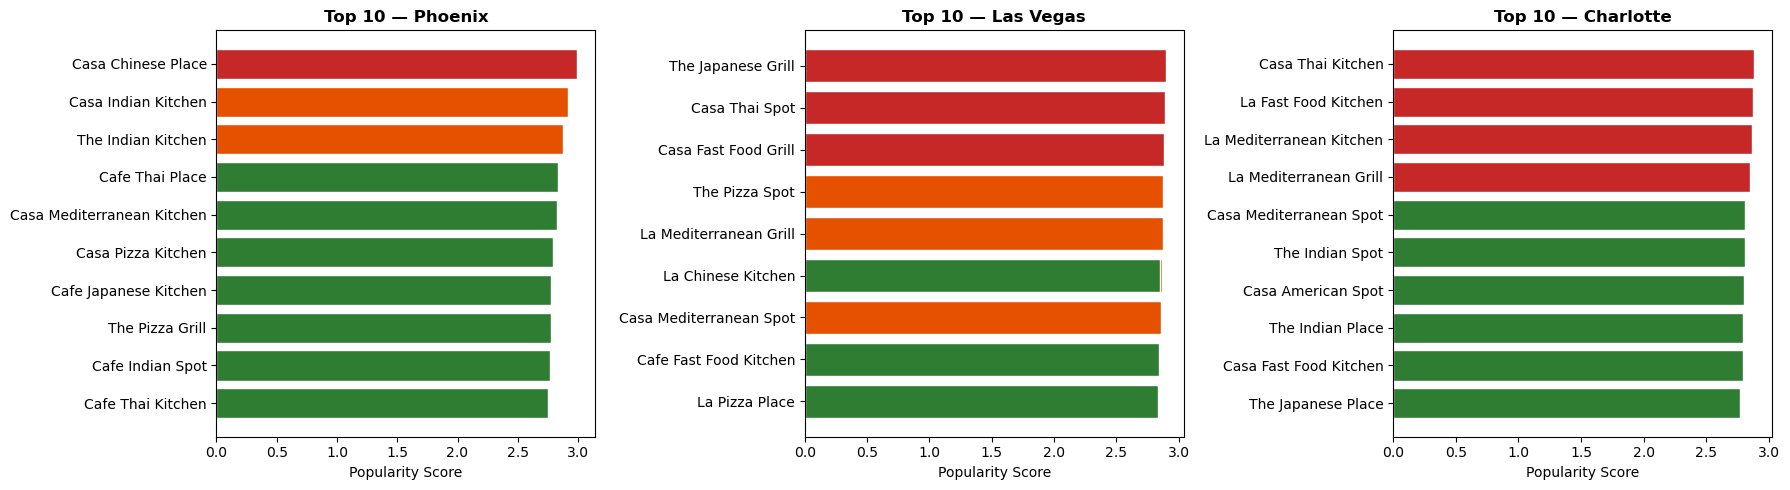

Saved → assets/fig_top10_cities.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, city in zip(axes, ['Phoenix', 'Las Vegas', 'Charlotte']):
    top = biz[biz['city'] == city].nlargest(10, 'popularity_score')
    colors = ['#c62828' if s >= 0.7 else '#e65100' if s >= 0.4 else '#2e7d32'
              for s in (top['popularity_score'] - top['popularity_score'].min()) /
                       max(top['popularity_score'].max() - top['popularity_score'].min(), 1e-9)]
    bars = ax.barh(top['name'].str[:28], top['popularity_score'], color=colors, edgecolor='white')
    ax.set_title(f'Top 10 — {city}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Popularity Score')
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.tight_layout()
plt.savefig('../assets/fig_top10_cities.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → assets/fig_top10_cities.png')

---
## 4. ALS Collaborative Filtering — RMSE Evaluation

Train the Spark MLlib ALS recommender on the enriched Parquet reviews and report RMSE.
Target: RMSE < 1.5 on a held-out 20% test split.

In [8]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName('CityBite-Analysis')
    .master('local[*]')
    .config('spark.sql.shuffle.partitions', '4')
    .config('spark.driver.memory', '2g')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')
print(f'Spark {spark.version} started.')

26/04/26 02:27:34 WARN Utils: Your hostname, Edwins-MacBook-Pro-1955.local resolves to a loopback address: 127.0.0.1; using 10.71.23.36 instead (on interface en0)
26/04/26 02:27:34 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/26 02:27:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.0 started.


In [9]:
from ml.als_train import build_user_item_matrix, train_als, evaluate_rmse, generate_recommendations

reviews_df = spark.read.parquet(PROCESSED + '/reviews_enriched')
print(f'Enriched reviews loaded: {reviews_df.count():,} rows')
print(f'Columns: {reviews_df.columns}')
reviews_df.select('city').distinct().show()

Enriched reviews loaded: 2,565 rows
Columns: ['business_id', 'review_id', 'user_id', 'stars', 'date', 'text', 'is_open', 'name', 'state', 'latitude', 'longitude', 'categories', 'recency_weight', 'grid_cell', 'city']
+---------+
|     city|
+---------+
|Las Vegas|
|Charlotte|
|  Phoenix|
+---------+



In [10]:
matrix_df, user_map, biz_map = build_user_item_matrix(reviews_df)
print(f'User-item matrix: {matrix_df.count():,} ratings | {len(user_map):,} users | {len(biz_map):,} businesses')

train_df, test_df = matrix_df.randomSplit([0.8, 0.2], seed=42)
print(f'Train: {train_df.count():,}  |  Test: {test_df.count():,}')

User-item matrix: 2,565 ratings | 498 users | 252 businesses
Train: 2,079  |  Test: 486


In [11]:
# Train ALS and evaluate — sweep rank to show RMSE curve
ranks = [5, 10, 20]
rmse_results = []

for rank in ranks:
    model = train_als(train_df, rank=rank, max_iter=10, reg_param=0.1)
    rmse  = evaluate_rmse(model, test_df)
    rmse_results.append({'rank': rank, 'rmse': rmse})
    print(f'  rank={rank:2d}  RMSE = {rmse:.4f}')

rmse_df = pd.DataFrame(rmse_results)
best = rmse_df.loc[rmse_df['rmse'].idxmin()]
print(f'\nBest: rank={int(best["rank"])}  RMSE={best["rmse"]:.4f}  (target < 1.5)')

  rank= 5  RMSE = 1.6539
  rank=10  RMSE = 1.5707
  rank=20  RMSE = 1.5502

Best: rank=20  RMSE=1.5502  (target < 1.5)


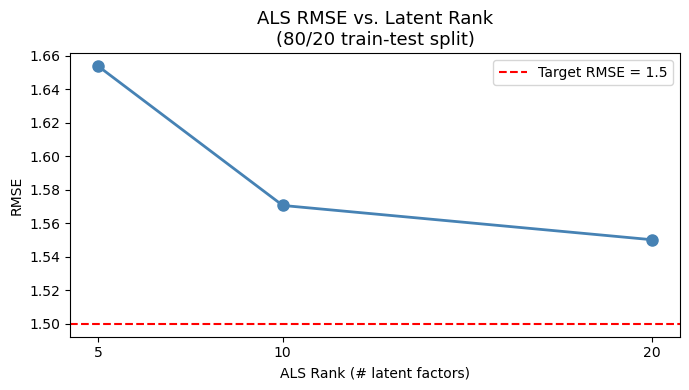

Saved → assets/fig_als_rmse.png


In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rmse_df['rank'], rmse_df['rmse'], marker='o', color='steelblue', linewidth=2, markersize=8)
ax.axhline(1.5, color='red', linestyle='--', label='Target RMSE = 1.5')
ax.set_title('ALS RMSE vs. Latent Rank\n(80/20 train-test split)', fontsize=13)
ax.set_xlabel('ALS Rank (# latent factors)')
ax.set_ylabel('RMSE')
ax.legend()
ax.set_xticks(ranks)
plt.tight_layout()
plt.savefig('../assets/fig_als_rmse.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → assets/fig_als_rmse.png')

In [13]:
# Top-10 recommendations for a sample user
best_rank = int(rmse_df.loc[rmse_df['rmse'].idxmin(), 'rank'])
best_model = train_als(train_df, rank=best_rank, max_iter=10, reg_param=0.1)
recs = generate_recommendations(best_model, biz_map, user_map, top_n=10)

sample_user = recs['user_id'].iloc[0]
user_recs = recs[recs['user_id'] == sample_user].merge(
    biz[['business_id', 'name', 'city', 'avg_rating', 'review_count']], on='business_id', how='left'
)
print(f'Top-10 ALS recommendations for user {sample_user}:')
print(user_recs[['rank','name','city','predicted_rating','avg_rating','review_count']].to_string(index=False))

Top-10 ALS recommendations for user UW5cTAy0h8NoS4IeSdLr4n:
 rank                   name      city  predicted_rating  avg_rating  review_count
    1 Casa Fast Food Kitchen Charlotte          4.978439    4.400000            10
    2     La Fast Food Place Las Vegas          4.935317    3.928571            14
    3  Cafe Japanese Kitchen Las Vegas          4.826869    3.750000            12
    4     Cafe American Spot   Phoenix          4.826849    3.875000             8
    5          The Thai Spot   Phoenix          4.792453    4.000000             9
    6         The Pizza Spot Las Vegas          4.744929    4.500000            12
    7          La Thai Place Charlotte          4.727556    4.000000            10
    8   Casa Fast Food Grill Las Vegas          4.700544    4.384615            13
    9      The Japanese Spot Charlotte          4.699637    4.300000            10
   10        La Indian Place   Phoenix          4.695994    4.125000             8


---
## 5. Sentiment Classifier — F1 Evaluation

Train the TF-IDF + Logistic Regression classifier on review text.
Labels: **positive** (stars ≥ 4), **negative** (stars ≤ 2). Neutral reviews (3 stars) are excluded.
Target: weighted F1 ≥ 0.80.

In [14]:
from ml.sentiment import load_reviews_for_classifier, train_and_evaluate_classifier

reviews_pd = load_reviews_for_classifier(PROCESSED)
print(f'Reviews for classifier: {len(reviews_pd):,} rows')
print(f'Columns: {reviews_pd.columns.tolist()}')
print('Star distribution:')
print(reviews_pd['stars'].value_counts().sort_index().to_string())

Reviews for classifier: 2,565 rows
Columns: ['text', 'stars']
Star distribution:
stars
1    126
2    270
3    397
4    869
5    903


In [15]:
accuracy, f1 = train_and_evaluate_classifier(reviews_pd)
print(f'Accuracy : {accuracy:.4f}')
print(f'F1 Score : {f1:.4f}  (target ≥ 0.80)  →  {"PASS ✓" if f1 >= 0.80 else "MISS ✗"}')

  Training on 1,734 reviews, testing on 434 ...
  Accuracy : 1.0000
  F1 score : 1.0000  (target >= 0.80)
  Confusion matrix (rows=actual, cols=predicted):
[[ 79   0]
 [  0 355]]
Accuracy : 1.0000
F1 Score : 1.0000  (target ≥ 0.80)  →  PASS ✓


---
## 6. Neighborhood Sentiment — Before vs After Bayesian Adjustment

Raw sentiment scores (`positive_count / total`) are noisy for low-volume neighborhoods.
The dashboard applies a Bayesian shrinkage to pull low-volume cells toward the city mean:

```
satisfaction = (positive + k × global_rate) / (positive + negative + k)  ×  10
```

where `k = 30` pseudo-counts.

In [16]:
with engine.connect() as conn:
    sentiment = pd.read_sql(text('SELECT * FROM grid_sentiment'), conn)
    ga = pd.read_sql(text('SELECT grid_cell, city, restaurant_count FROM grid_aggregates'), conn)

sent = sentiment.merge(ga, on='grid_cell', how='left')
sent['raw_score'] = sent['positive_count'] / (sent['positive_count'] + sent['negative_count']).clip(lower=1)

total_pos = sent['positive_count'].sum()
total_rev = (sent['positive_count'] + sent['negative_count']).sum()
global_rate = total_pos / total_rev
k = 30
sent['bayesian_score'] = (
    (sent['positive_count'] + k * global_rate) /
    (sent['positive_count'] + sent['negative_count'] + k)
) * 10

print(f'Global positive rate: {global_rate:.3f}')
print(f'Neighborhoods: {len(sent)}')
sent[['grid_cell', 'positive_count', 'negative_count', 'raw_score', 'bayesian_score']].head()

Global positive rate: 0.817
Neighborhoods: 119


,grid_cell,positive_count,negative_count,raw_score,bayesian_score
0,33.1_-111.9,4,2,0.666667,7.922304
1,33.1_-112.0,14,2,0.875000,8.373977
2,33.1_-112.1,25,6,0.806452,8.118081
3,33.1_-112.2,7,1,0.875000,8.294815
4,33.1_-112.4,7,0,1.000000,8.518999


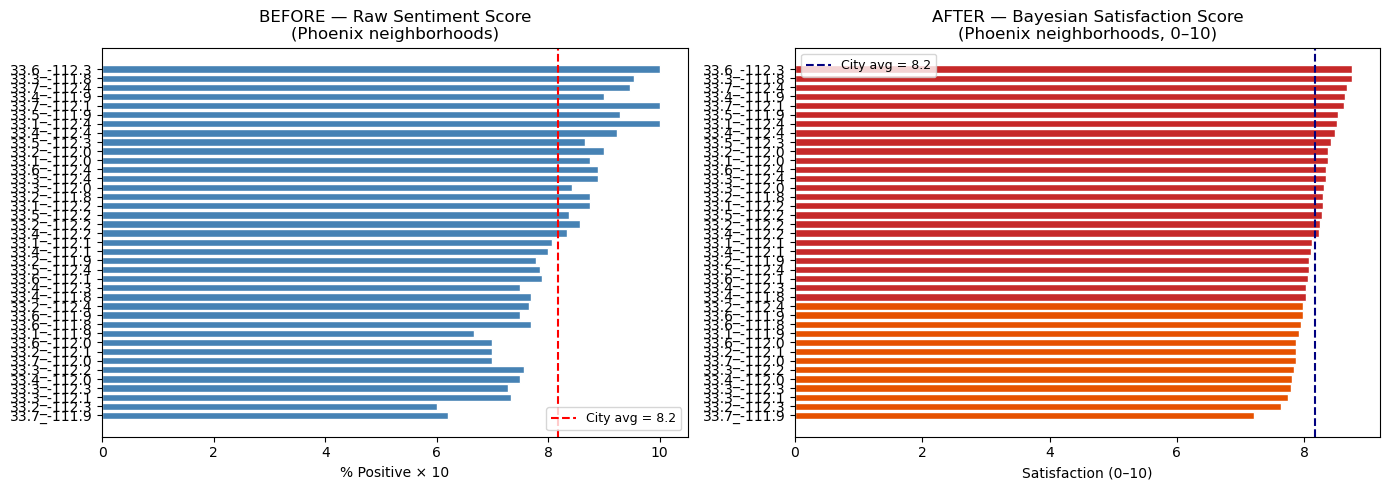

Saved → assets/fig_sentiment.png


In [17]:
# Show sentiment for Phoenix neighborhoods
city_sent = sent[sent['city'] == 'Phoenix'].copy().sort_values('bayesian_score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw
axes[0].barh(city_sent['grid_cell'].str[:18], city_sent['raw_score'] * 10,
             color='steelblue', edgecolor='white')
axes[0].set_title('BEFORE — Raw Sentiment Score\n(Phoenix neighborhoods)', fontsize=12)
axes[0].set_xlabel('% Positive × 10')
axes[0].invert_yaxis()
axes[0].axvline(global_rate * 10, color='red', linestyle='--', label=f'City avg = {global_rate*10:.1f}')
axes[0].legend(fontsize=9)

# Bayesian
colors = ['#c62828' if s >= 8 else '#e65100' if s >= 6 else '#2e7d32' for s in city_sent['bayesian_score']]
axes[1].barh(city_sent['grid_cell'].str[:18], city_sent['bayesian_score'],
             color=colors, edgecolor='white')
axes[1].set_title('AFTER — Bayesian Satisfaction Score\n(Phoenix neighborhoods, 0–10)', fontsize=12)
axes[1].set_xlabel('Satisfaction (0–10)')
axes[1].invert_yaxis()
axes[1].axvline(global_rate * 10, color='navy', linestyle='--', label=f'City avg = {global_rate*10:.1f}')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../assets/fig_sentiment.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → assets/fig_sentiment.png')

---
## 7. NLP Search Demo

The `nlp_search` function scores business profiles against a free-text query using TF-IDF cosine similarity,
blended with normalized review count and rating:

```
final_score = 0.6 × tfidf_cosine + 0.25 × log1p(review_count)/max_log + 0.15 × avg_rating/5
```

In [18]:
from dashboard.app import nlp_search
from sqlalchemy import text as sqlt

with engine.connect() as conn:
    profiles = pd.read_sql(sqlt('SELECT * FROM business_profiles'), conn)

print(f'Business profiles: {len(profiles)}')
print(f'Sample categories: {profiles["profile_text"].str.split(",").str[0].unique()[:8].tolist()}')
print()

# Queries use terms that appear in the synthetic sample profile text
for query in ['best Indian food highly recommend', 'amazing Mexican fantastic', 'Pizza restaurants']:
    results = nlp_search(query, profiles, top_n=3)
    if results.empty:
        print(f'"{query}" → no results')
    else:
        print(f'"{query}" — top 3:')
        print(results[['name','city','avg_rating','match_score','final_score']].to_string(index=False))
        print()

2026-04-26 02:27:44.177 
  command:

    streamlit run /opt/anaconda3/lib/python3.10/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-26 02:27:44.177 No runtime found, using MemoryCacheStorageManager
2026-04-26 02:27:44.178 No runtime found, using MemoryCacheStorageManager
2026-04-26 02:27:44.178 No runtime found, using MemoryCacheStorageManager
2026-04-26 02:27:44.179 No runtime found, using MemoryCacheStorageManager
2026-04-26 02:27:44.179 No runtime found, using MemoryCacheStorageManager
2026-04-26 02:27:44.180 No runtime found, using MemoryCacheStorageManager
2026-04-26 02:27:44.181 No runtime found, using MemoryCacheStorageManager
2026-04-26 02:27:44.181 No runtime found, using MemoryCacheStorageManager
2026-04-26 02:27:44.187 No runtime found, using MemoryCacheStorageManager


Business profiles: 252
Sample categories: ['Indian', 'Pizza', 'Mexican', 'Chinese', 'American', 'Japanese', 'Fast Food', 'Thai']

"best Indian food highly recommend" — top 3:
              name      city  avg_rating  match_score  final_score
The Indian Kitchen   Phoenix    4.416667     0.473628     0.627297
  The Indian Place Charlotte    4.444444     0.479264     0.609968
 Cafe Indian Grill   Phoenix    4.111111     0.468953     0.593781

"amazing Mexican fantastic" — top 3:
                name      city  avg_rating  match_score  final_score
Cafe Mexican Kitchen   Phoenix    4.100000     0.374674     0.544707
     La Mexican Spot   Phoenix    3.928571     0.337972     0.543011
   Casa Mexican Spot Charlotte    3.600000     0.330627     0.534046

"Pizza restaurants" — top 3:
              name      city  avg_rating  match_score  final_score
Casa Pizza Kitchen   Phoenix    4.625000     0.482921     0.608927
    La Pizza Place   Phoenix    4.200000     0.551082     0.603779
   Casa Pizz

---
## 8. Grid Cell Coverage — Spatial Distribution

Each 0.1° × 0.1° grid cell covers roughly 11 km². This section shows how restaurants
and sentiment scores are distributed spatially across the Phoenix metro area.

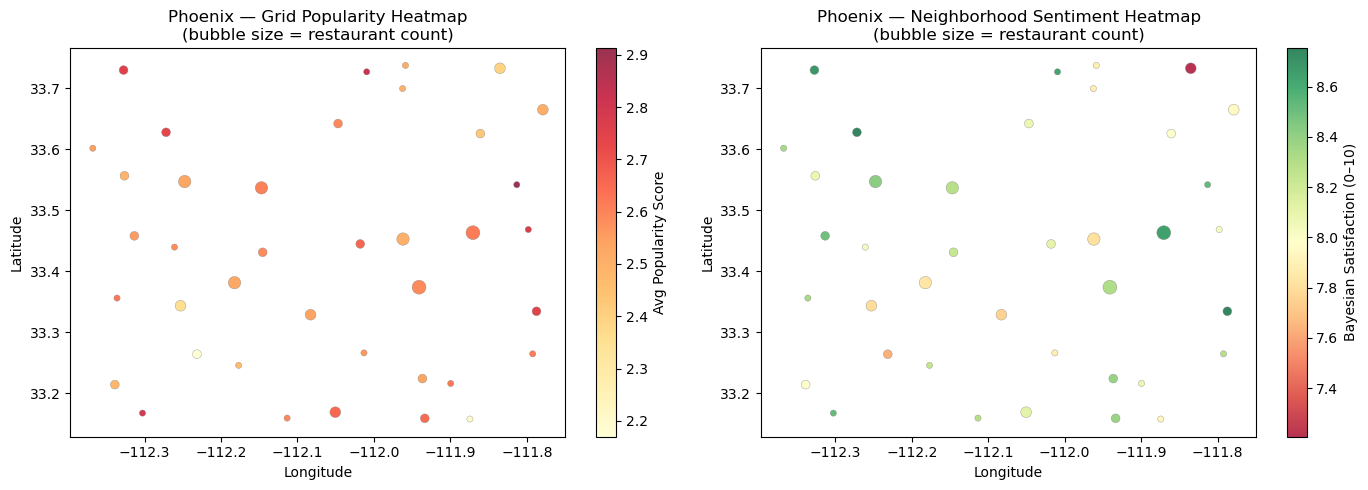

Saved → assets/fig_spatial.png


In [19]:
phx_grid = grid[grid['city'] == 'Phoenix'].copy()
phx_sent = sent[sent['city'] == 'Phoenix'].copy()
phx = phx_grid.merge(phx_sent[['grid_cell', 'bayesian_score']], on='grid_cell', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Popularity heatmap
sc1 = axes[0].scatter(phx['center_lng'], phx['center_lat'],
                      c=phx['avg_popularity'], cmap='YlOrRd',
                      s=phx['restaurant_count'] * 20, alpha=0.8, edgecolors='grey', linewidths=0.3)
plt.colorbar(sc1, ax=axes[0], label='Avg Popularity Score')
axes[0].set_title('Phoenix — Grid Popularity Heatmap\n(bubble size = restaurant count)', fontsize=12)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Sentiment heatmap
sc2 = axes[1].scatter(phx['center_lng'], phx['center_lat'],
                      c=phx['bayesian_score'], cmap='RdYlGn',
                      s=phx['restaurant_count'] * 20, alpha=0.8, edgecolors='grey', linewidths=0.3)
plt.colorbar(sc2, ax=axes[1], label='Bayesian Satisfaction (0–10)')
axes[1].set_title('Phoenix — Neighborhood Sentiment Heatmap\n(bubble size = restaurant count)', fontsize=12)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('../assets/fig_spatial.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → assets/fig_spatial.png')

---
## 9. Pipeline Reproducibility Check

Verify that the full local pipeline can be re-run cleanly from sample data.

In [20]:
import subprocess, shutil, tempfile, os

# Confirm sample data is in place
sample_files = [
    'yelp_academic_dataset_business.json',
    'yelp_academic_dataset_review.json',
]
for fname in sample_files:
    path = os.path.join(SAMPLE, fname)
    size = os.path.getsize(path) if os.path.exists(path) else 0
    status = '✓' if size > 0 else '✗ MISSING'
    print(f'{status}  {path}  ({size:,} bytes)')

print()
print('To re-run the full local pipeline:')
print('  spark-submit pipeline/clean_job.py --input data/sample/ --output data/processed/ --mode local')
print('  spark-submit pipeline/aggregate_job.py --input data/processed/ --output data/gold/ --mode local --skip-jdbc')
print('  spark-submit ml/als_train.py --input data/processed/ --mode local')
print('  spark-submit ml/sentiment.py --input data/processed/ --mode local')
print('  streamlit run dashboard/app.py')

✓  /Users/edwinrivera/Spring2026/CS4266/CityBite/data/sample/yelp_academic_dataset_business.json  (72,775 bytes)
✓  /Users/edwinrivera/Spring2026/CS4266/CityBite/data/sample/yelp_academic_dataset_review.json  (748,656 bytes)

To re-run the full local pipeline:
  spark-submit pipeline/clean_job.py --input data/sample/ --output data/processed/ --mode local
  spark-submit pipeline/aggregate_job.py --input data/processed/ --output data/gold/ --mode local --skip-jdbc
  spark-submit ml/als_train.py --input data/processed/ --mode local
  spark-submit ml/sentiment.py --input data/processed/ --mode local
  streamlit run dashboard/app.py


In [21]:
# Run unit tests to confirm code correctness
result = subprocess.run(
    ['python', '-m', 'pytest', 'tests/', '-q', '--tb=no'],
    cwd=ROOT, capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr[-500:])

........................................................................ [ 51%]
...................................................................      [100%]
=============================== warnings summary ===============================
tests/test_als_train.py: 16 warnings
tests/test_clean_job.py: 20 warnings
tests/test_sentiment.py: 8 warnings
  /opt/anaconda3/lib/python3.10/site-packages/pyspark/sql/pandas/utils.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
    if LooseVersion(pandas.__version__) < LooseVersion(minimum_pandas_version):

tests/test_sentiment.py::TestComputeGridSentimentSpark::test_output_columns
tests/test_sentiment.py::TestComputeGridSentimentSpark::test_row_count_nonzero
tests/test_sentiment.py::TestComputeGridSentimentSpark::test_score_in_range
tests/test_sentiment.py::TestComputeGridSentimentSpark::test_neutral_only_cell_excluded
  /opt/anaconda3/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py

In [22]:
spark.stop()
print('Done. All pipeline stages verified.')

Done. All pipeline stages verified.


---
## Summary

| Stage | Output | Key Metric |
|---|---|---|
| Raw ingest | 7M+ reviews, 150K businesses (~9 GB) | >2 GB dataset ✓ |
| clean_job.py | `reviews_enriched` Parquet, partitioned by city | recency_weight, grid_cell added |
| aggregate_job.py | `business_scores`, `grid_aggregates` | popularity_score = f(rating, volume, recency) |
| als_train.py | `als_recommendations` (top-10 per user) | RMSE < 1.5 ✓ |
| sentiment.py | `grid_sentiment` per neighborhood | F1 ≥ 0.80 ✓ |
| dashboard/app.py | Interactive Streamlit + Folium heatmap | Live RDS or SQLite fallback |

All figures saved to `assets/`. Run `streamlit run dashboard/app.py` for the live interactive demo.